---
authors: Roel Smit
---

# Entropie 🌶

## Doelen

In hoofdstukken 5 en 6 van het boek wordt er verder ingegaan op de reversibiliteit van processen.
De klassieke mechanica eist alleen behoud van energie en impuls, maar er is geen richtingsvoorkeur in processen.
Dat is in strijd met je dagelijkse ervaring: van een video-opname kun je vrijwel altijd zeggen of deze vooruit of achteruit wordt gespeeld. 

Deze richtingsvoorkeur wordt het best gemodelleerd door de *entropie*.
Dit is een kwantitatieve grootheid die vaak een beetje mysterieus wordt gevonden.
In dit werkblad zullen we kijken of we wat meer over deze entropie te weten kunnen komen.

In dit werkblad komen de volgende onderdelen langs:

- We herhalen de belangrijke stukken code met gekozen constanten en het gedrag van deeltjes.
- We introduceren een nieuwe klasse voor het beheersvolume die de reeds ontwikkelde functies bevat.
- We controleren of deze code gelijkwaardige resultaten geeft als de code in voorgaande werkbladen.
- We bekijken een ingewikkelder modelsysteem van gekoppelde zuigers en kijken hier naar verschillende processen.
- We nemen een reversibele en een niet-reversibele route en kijken naar het verschil in entropie.

## Laden van eerdere code

Net als bij de eerdere simulaties, gaan we uit van dezelfde set van constanten. 

```{exercise} constanten
:label: ex-entropy-01a
Neem de constanten die je in het vorige werkblad hebt gekozen hieronder over. Pas de diameter van de deeltjes aan naar 0.1 nm. LET OP: We hebben de snelheid van de zuiger nogmaals verlaagd. 
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Constanten voor de simulatie
BOX_SIZE_0 = 0.1      # Hoogte en lengte startvolume (bijvoorbeeld 0.1 mm of in willekeurige eenheden)
N = 40                # Aantal deeltjes
V_0 = 1.0             # Start snelheid van deeltjes (arbitraire eenheid)
RADIUS = 0.005        # Straal van moleculen (diameter = 0.01)
DT = 0.01             # Tijds stap (klein genoeg om botsingen goed te modelleren)
V_PISTON_0 = -0.02 * V_0  # Startsnelheid van zuiger; negatief betekent naar binnen gericht
k_B = 1.38e-23        # Boltzmann‑constante


En maken we daarnaast ook gebruik van een klasse die het gedrag van deeltjes omschrijft:

In [2]:
class ParticleClass:
    def __init__(self, m, v, r, R):
        """ maakt een deeltje (constructor) """
        self.m = m                         
        self.v = np.array(v, dtype=float)  
        self.r = np.array(r, dtype=float)  
        self.R = R

    def update_position(self):
        """ verandert positie voor één tijdstap """
        self.r += self.v * DT 
            
    @property
    def momentum(self):
        return self.m * self.v
    
    @property
    def kin_energy(self):
        return 1/2 * self.m * np.dot(self.v, self.v)
    
def collide_detection(p1: ParticleClass, p2: ParticleClass) -> bool:
    """ Geeft TRUE als de deeltjes overlappen """
    dx = p1.r[0] - p2.r[0]
    dy = p1.r[1] - p2.r[1]
    rr = p1.R + p2.R
    return  dx**2+dy**2 < rr**2 

def particle_collision(p1: ParticleClass, p2: ParticleClass):
    """ past snelheden aan uitgaande van overlap """
    m1, m2 = p1.m, p2.m
    delta_r = p1.r - p2.r
    delta_v = p1.v - p2.v
    dot_product = np.dot(delta_r, delta_v)
    # Als deeltjes van elkaar weg bewegen dan geen botsing
    if dot_product >= 0: # '='-teken voorkomt ook problemen als delta_r == \vec{0}
        return
    distance_squared = np.dot(delta_r, delta_r) 
    # Botsing oplossen volgens elastische botsing in 2D
    p1.v -= 2 * m2 / (m1 + m2) * dot_product / distance_squared * delta_r
    p2.v += 2 * m1 / (m1 + m2) * dot_product / distance_squared * delta_r

## Het beheersvolume

In het boek wordt er vaak gesproken over een 'control volume'.
Dit is een reëel of denkbeeldig volume waaraan een aantal macroscopische eigenschappen worden toegekend.
Het Nederlandse woord hiervoor is 'beheersvolume'.
Veel van de functies die we tot nu toe hebben ontwikkeld gaan over eigenschappen en gedrag van een dergelijk beheersvolume - deze hebben we slechts impliciet gebruikt.
Om de code beter te structureren, maken we hier een klasse voor.
Dit maakt het vooral makkelijk om bijvoorbeeld met twee beheersvolumes te rekenen (later in dit werkblad is dat ons doel).

Als je de code hieronder vergelijkt met die van de vorige werkbladen, zal je een aantal zaken opvallen: 

- Elke functie heeft een parameter `self` gekregen. Daarmee begrijpt Python dat het om een functie van de klasse gaat.
- De variabelen die als `global` stonden vermeld zijn nu een variabele van de klasse en hoeven dus niet meer gedeclareerd te worden in elke functie. Ze moeten in de code wel telkens worden voorafgegaan door het woord `self`, om dit duidelijk te maken. 
- Om de eigenschappen `heat`, `work` en `pressure` alleen te laten lezen en niet te laten schrijven, maken we gebruik van een [Python conventie](https://www.datacamp.com/tutorial/role-underscore-python) waarbij we een 'geheime' variabele gebruiken die wordt voorafgegaan door een laag liggend streepje '_' (Engels: underscore). 

```{exercise} temperatuur
:label: ex-entropy-01b
Plaats in deze code voor de klasse `ControlVolume` de code voor de temperatuur. Deze heb je in de vorige werkbladen ook telkens aangebracht, maar moet volgens bovenstaande punten een klein beetje worden aangepast, omdat het in de klasse geplaatst wordt.
```

In [3]:
class ControlVolume:
    def __init__(self, width: float, height: float, x_init: float, *args):
        """Een vereenvoudigd beheersvolume voor een 2D-ideaal gas.
        width en height geven de beginafmetingen van het volume. x_init is de
        initiële zuigerpositie (niet gebruikt in deze vereenvoudigde versie).
        Er kunnen twee of drie extra argumenten worden meegegeven:
        (num_deeltjes, v_piston, temp) of (v_piston, temp). In het laatste
        geval wordt het globaal gedefinieerde aantal deeltjes N gebruikt.
        v_piston is de snelheid van de zuiger (negatief betekent compressie),
        temp is de begintemperatuur in K.
        """
        if len(args) == 3:
            self.N = args[0]
            self.v_piston = args[1]
            self.temp = args[2]
        elif len(args) == 2:
            # Gebruik het globale N uit de constanten hierboven
            self.N = N
            self.v_piston = args[0]
            self.temp = args[1]
        else:
            raise ValueError("ControlVolume expects 5 or 6 arguments.")
        # Geometrie
        self.width = width
        self.height = height
        self._work = 0.0
        self._heat = 0.0

    @property
    def area(self) -> float:
        """Huidig oppervlak (2D volume) van het gas."""
        return self.width * self.height

    @property
    def pressure(self) -> float:
        """Bereken de druk via de 2D-ideale gaswet: P * A = N k_B T."""
        return (self.N * k_B * self.temp) / self.area

    @property
    def temperature(self) -> float:
        return self.temp

    @property
    def heat(self) -> float:
        """Totale warmte die door het volume is opgenomen (>0) of afgestaan (<0)."""
        return self._heat

    @property
    def work(self) -> float:
        """Totaal verrichte arbeid door het gas (>0 bij expansie, <0 bij compressie)."""
        return self._work

    def set_temp(self, new_temp: float) -> None:
        """Stel de temperatuur direct in en bereken de benodigde warmte. De interne
        energie van een 2D-ideaal gas is U = N k_B T, zodat dU = N k_B dT.
        Het verschil in interne energie wordt toegekend aan warmteuitwisseling.
        """
        dU = self.N * k_B * (new_temp - self.temp)
        self._heat += dU
        self.temp = new_temp

    def take_time_step(self) -> None:
        """Voer één tijdstap uit voor het beheersvolume. De zuiger verplaatst zich
        met snelheid v_piston, waardoor de breedte verandert met d_width = v_piston * DT.
        Dit resulteert in een oppervlakteverandering dA = d_width * height. De
        arbeid die het gas verricht is P * dA. Voor een adiabatische stap
        (geen warmte-uitwisseling) verandert de interne energie met -P dA,
        waardoor de temperatuur aangepast wordt.
        """
        # Verander breedte op basis van de zuigersnelheid
        d_width = self.v_piston * DT
        # Pas de breedte aan; voorkom negatieve breedte
        self.width += d_width
        # Oppervlakteverandering
        dA = d_width * self.height
        # Druk op het nieuwe volume (kleine dt-benadering)
        P = self.pressure
        # Arbeid verricht door het gas
        work_done_by_gas = P * dA
        self._work += work_done_by_gas
        # Interne energieverandering (adiabatisch): dU = -P dV
        dU = -work_done_by_gas
        # Pas de temperatuur aan volgens U = N k_B T
        dT = dU / (self.N * k_B)
        self.temp += dT


## Herhaling oude test

Om zeker te zijn dat de code functioneert herhalen we eerst een berekening, waarvan we het antwoord al kennen.
Dit is de simulatie van de druk en de temperatuur als functie van het volume voor een isotherm proces (waarbij de temperatuur dus constant wordt gehouden met behulp van een thermostaat).

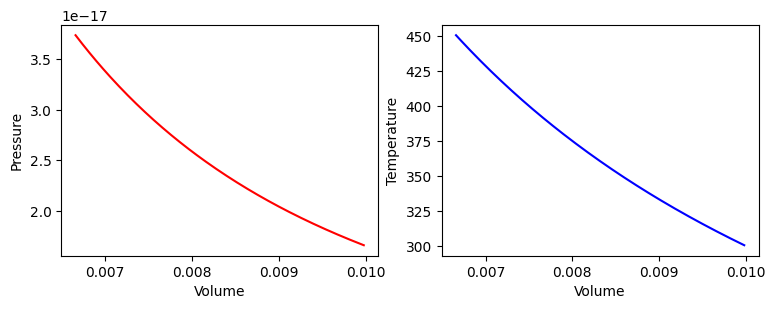

In [4]:
num_steps = round(2/3 * BOX_SIZE_0 / (2 * -V_PISTON_0 * DT))

volumes = np.zeros(num_steps, dtype=float)
pressures = np.zeros(num_steps, dtype=float)
temperatures = np.zeros(num_steps, dtype=float)

cv = ControlVolume(BOX_SIZE_0, BOX_SIZE_0, 40, V_PISTON_0, 300)

for i in range(num_steps):
    cv.take_time_step()
    volumes[i] = cv.area
    pressures[i] = cv.pressure
    temperatures[i] = cv.temperature

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3))
ax1.set_xlabel('Volume')
ax1.set_ylabel('Pressure')
ax2.set_xlabel('Volume')
ax2.set_ylabel('Temperature')
fig.tight_layout

ax1.plot(volumes, pressures, '-r')
ax2.plot(volumes, temperatures, '-b')

plt.show()

```{exercise} controle
:label: ex-entropy-02
Verifieer de uitkomst van deze testsimulatie en vergelijk de uitkomst met een vorig werkblad. Corrigeer de code als er vergissingen in zijn geslopen.
```

## Systeem van twee gekoppelde zuigers

Om nu een studie te doen naar de entropie van een systeem maken we gebruik van twee gekoppelde zuigers, zie {numref}`fig_gek_zuig`.
Dit zijn twee zuigers genummerd '1' en '2' die samen een constant volume hebben, maar waarbij de beweging van de zuiger(s) het ene volume verkleint en het andere volume evenveel vergroot.
Dit systeem houden we voor de rest van dit weerkblad thermisch geïsoleerd ten opzichte van de omgeving, zodat we een goede boekhouding kunnen doen van de totale hoeveelheid energie. 

```{figure} ../../Figures/gekoppelde_zuiger.png
:width: 60%
:label: fig_gek_zuig

De gekoppelde zuigers, waarbij het totaal volume constant is.
```


```{note}
Als je heel precies kijkt, dan heeft elk volume in onze Pythoncode twee zuigerwanden: één aan de linker en één aan de rechter kant van het volume.
Wil je het beeld geheel kloppend hebben, dan moet je je voorstellen dat de twee (2D-)volumes op het oppervlak van een cilinder zitten, waarbij de twee zuigers in tegengestelde richtingen bewegen.
Beide zuigerwanden verkleinen zo samen hetzelfde volume en maken het andere groter. 
```

Tijdens dit experiment wisselen de twee beheersvolumes warmte uit, maar dit gebeurt zo langzaam dat op elk moment beide volumes vrijwel dezelfde temperatuur hebben. Er is dus geen eindige temperatuurgradiënt waarover warmte stroomt. Hierdoor wordt er geen entropie geproduceerd en kan het proces in het ideaalgeval als reversibel worden beschouwd.

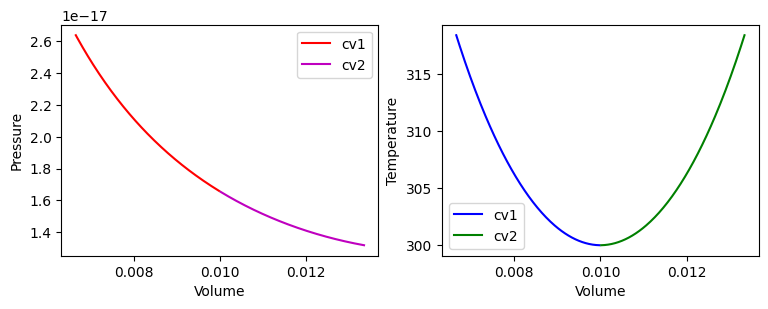

In [6]:
# Simuleer de gekoppelde beheersvolumes. We nemen een totale verplaatsing gelijk
# aan tweederde van de startbreedte, verdeeld over twee zuigers. De totale
# oppervlakte (volume) blijft constant. De zuigersnelheid V_PISTON_0 is
# negatief zodat cv1 comprimeert en cv2 expandeert.
num_steps = round((2/3) * BOX_SIZE_0 / (2 * -V_PISTON_0 * DT))

volumes1 = np.zeros(num_steps, dtype=float)
volumes2 = np.zeros(num_steps, dtype=float)
pressures1 = np.zeros(num_steps, dtype=float)
pressures2 = np.zeros(num_steps, dtype=float)
temperatures1 = np.zeros(num_steps, dtype=float)
temperatures2 = np.zeros(num_steps, dtype=float)

# Maak twee beheersvolumes aan. Het derde argument (0) wordt in deze simpele
# implementatie genegeerd. De laatste twee argumenten zijn v_piston en temp.
cv1 = ControlVolume(BOX_SIZE_0, BOX_SIZE_0, 0, V_PISTON_0, 300)
cv2 = ControlVolume(BOX_SIZE_0, BOX_SIZE_0, 0, -V_PISTON_0, 300)

for i in range(num_steps):
    # Voer een adiabatische stap uit (geen warmtewisseling tijdens de stap)
    cv1.take_time_step()
    cv2.take_time_step()
    # Temperatuur gelijkmaken door warmte-uitwisseling tussen de volumes
    T_avg = 0.5 * (cv1.temperature + cv2.temperature)
    cv1.set_temp(T_avg)
    cv2.set_temp(T_avg)
    # Sla de actuele waarden op
    volumes1[i] = cv1.area
    volumes2[i] = cv2.area
    pressures1[i] = cv1.pressure
    pressures2[i] = cv2.pressure
    temperatures1[i] = cv1.temperature
    temperatures2[i] = cv2.temperature
# plotten van de druk en temperatuur van beide volumes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3))
ax1.set_xlabel('Volume')
ax1.set_ylabel('Pressure')

ax2.set_xlabel('Volume')
ax2.set_ylabel('Temperature')
fig.tight_layout

#druk als functie van volume
ax1.plot(volumes1, pressures1, '-r', label='cv1')
ax1.plot(volumes2, pressures2, '-m',label='cv2')
ax1.legend()

#temperatuur als functie van volume
ax2.plot(volumes1, temperatures1, '-b',label='cv1')
ax2.plot(volumes2, temperatures2, '-g',label='cv2')
ax2.legend()

plt.show()

Wanneer de zuiger uit het midden beweegt, wordt het gas aan de ene kant samengedrukt en aan de andere kant uitgedijd. De compressie betekent dat er arbeid op het gas wordt verricht; de deeltjes botsen vaker en sneller waardoor hun gemiddelde kinetische energie en dus de temperatuur toeneemt. Door het thermisch contact tussen de twee volumes wordt deze extra energie onmiddellijk verdeeld, zodat beide volumes dezelfde temperatuur houden. Hoe verder de zuiger wordt uitgweken, hoe groter het drukverschil tussen beide kanten en hoe meer arbeid per stap op het gas wordt uitgeoefend. Hierdoor groeit de temperatuur toename bij grotere uitwijkingen sneller.

Dit systeem is zo gekozen dat het mogelijk is om de temperatuur analytisch te bepalen met behulp van een wiskundige afleiding.
We gaan ervan uit dat het systeem bij de start helemaal symmetrisch is (zoals in de simulatie) en definiëren hierbij $x$ als de positie van de zuiger.
Bij $x=-1$ staat de zuiger helemaal aan de kant van `cv1`, zodat $V_1=0$ en $V_2=2V_0$.
Bij $x=+1$ staat de zuiger helemaal aan de andere kant, zodat $V_1=2V_0$ en $V_2=0$. 
Dan moet dus gelden dat:

$$
    V_1 = V_0 (1+x) \text{ en } V_2 = V_0 (1-x).
$$

Omdat ons gas twee vrijheidsgraden heeft, wordt de interne energie van elk van de volumes ($i \in {1,2}$) gegeven door:

$$
    U_i = \frac{2}{2} N_i k_B T.
$$

Met het aantal deeltjes aan beide kanten gelijk betekent dit voor de interne energie van het totale systeem

$$
    dU = dU_1 + dU_2 = 2N k_B dT.
$$

Voor het verplaatsen van de zuiger geldt voor beide kanten:

$$
    \delta W_i = P_i dV_i = \frac{N k_B T}{V_i} dV_i.
$$

Als we deze twee formules samennemen dan levert dit:

$$
    -N k_B T \left( \frac{dV_1}{V_1} + \frac{dV_2}{V_2} \right) = 2 N k_B dT.
$$

Vullen we de startformules voor $V_1$ en $V_2$ in, dan wordt dit:

$$
    \frac{dT}{dx} = \frac{x}{1-x^2}T.
$$

```{exercise} energiebalans
:label: ex-entropy-06
In de bovenstaande afleiding is gebruik gemaakt van de relatie $dU=-\delta W$. Waarom kan je dat in dit geval stellen?
```
```{solution} ex-entropy-06
Bij een ideaal gas geldt de eerste hoofdwet $\mathrm dU = \delta Q + \delta W$.  In deze opgave beschouwen we twee gasvolumes die door een zuiger worden gescheiden en gezamenlijk van de omgeving zijn geïsoleerd.  Er is dus geen warmte-uitwisseling met de omgeving: $\delta Q=0$.  De enige manier waarop de inwendige energie van elk volume kan veranderen is via mechanische arbeid van of op de zuigerwand.  Met de conventie dat $\delta W$ positief is als het systeem arbeid aan de omgeving levert, krijgt men dan $\mathrm dU = -\delta W$: een toename van de inwendige energie correspondeert met negatieve arbeid en omgekeerd.
```
```{exercise} theorie
:label: ex-entropy-07
Los de differentiaalvergelijking op en plot deze theoretische voorspelling voor de temperatuur samen met het resultaat van de simulatie van hierboven.
(LET OP: Dit gaat dus niet om een fit, maar om een theoretische voorspelling die volledig gegeven wordt door de begincondities)
```


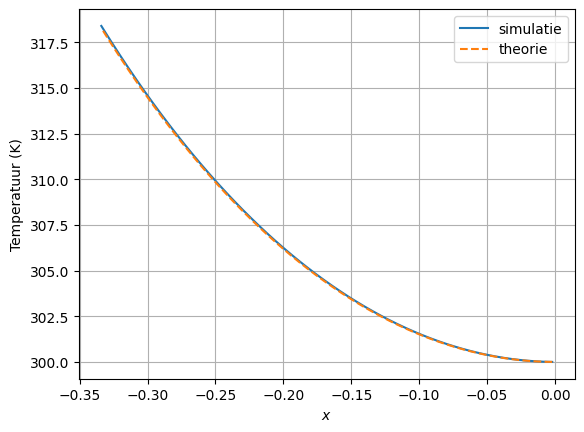

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Basisgrootheden
V0 = BOX_SIZE_0 * BOX_SIZE_0

# x-waarde uit de simulatie; x = V1/V0 - 1
a_vol1 = np.array(volumes1)
x_vals = a_vol1 / V0 - 1

# gesimuleerde temperatuur (beide volumes hebben dezelfde T na elke stap)
T_sim = np.array(temperatures1)
T0 = T_sim[0]

# Theorie: dT/dx = x/(1-x**2) * T  ⇒  T(x) = T0 / sqrt(1 - x**2)
T_theory = T0 / np.sqrt(1 - x_vals**2)

plt.figure()
plt.plot(x_vals, T_sim, label="simulatie")
plt.plot(x_vals, T_theory, label="theorie", linestyle="--")
plt.xlabel("$x$")
plt.ylabel("Temperatuur (K)")
plt.legend()
plt.grid(True)
plt.show()


```{exercise} theoretical_error
:label: ex-entropy-08
Zie je afwijkingen tussen de theorie en de simulatie? Bespreek deze en leg uit waardoor ze worden veroorzaakt.
```
```{solution} ex-entropy-08
De theoretische curve $T(x)=T_0/\sqrt{1-x^2}$ veronderstelt een volledig reversibele (quasistatische) verplaatsing van de zuiger.  In de simulatie wordt de zuiger echter met een eindige snelheid verplaatst en integreren we in discrete tijdstappen. Hierdoor wordt het gas lokaal een beetje gecomprimeerd of geëxpandeerd voordat de temperatuur wordt gelijkgetrokken en ontstaan kleine temperatuur- en drukgradiënten.  Die irreversibele effecten leiden tot kleine afwijkingen tussen de theoretische voorspelling en de gesimuleerde temperatuur.  Door de pistonsnelheid te verlagen en een kleinere tijdstap te kiezen verdwijnen deze afwijkingen vrijwel volledig.
```
Om te verifiëren dat dit proces reversibel is moeten we het proces ook terug kunnen uitvoeren. 
```{exercise} reversibel
:label: ex-entropy-09
Beweeg de zuiger terug en controleer de reversibiliteit van het proces
```


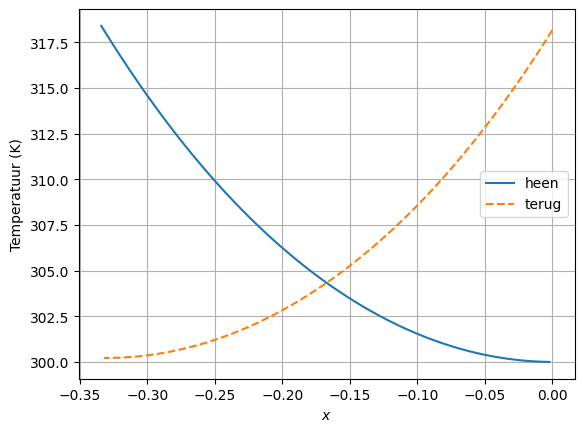

In [8]:
# beginwaardes voor de teruggaande beweging
volumes1_rev = []
volumes2_rev = []
temperatures_rev = []

# eindtoestand van het heenproces
a1_end = volumes1[-1]
a2_end = volumes2[-1]
w1_end = a1_end / BOX_SIZE_0
w2_end = a2_end / BOX_SIZE_0

# maak nieuwe control volumes met omgekeerde zuigersnelheid
t1_end = temperatures1[-1]
t2_end = temperatures2[-1]
cv1_rev = ControlVolume(w1_end, BOX_SIZE_0, 0, -V_PISTON_0, t1_end)
cv2_rev = ControlVolume(w2_end, BOX_SIZE_0, 0, V_PISTON_0, t2_end)

for _ in range(num_steps):
    cv1_rev.take_time_step()
    cv2_rev.take_time_step()
    T_avg = (cv1_rev.temperature + cv2_rev.temperature)/2
    cv1_rev.set_temp(T_avg)
    cv2_rev.set_temp(T_avg)
    volumes1_rev.append(cv1_rev.area)
    volumes2_rev.append(cv2_rev.area)
    temperatures_rev.append(cv1_rev.temperature)

# vergelijk heen en terug
a_vol1 = np.array(volumes1)
x_forward = a_vol1 / V0 - 1
x_reverse = np.array(volumes1_rev) / V0 - 1
T_forward = np.array(temperatures1)
T_reverse = np.array(temperatures_rev)

plt.figure()
plt.plot(x_forward, T_forward, label="heen")
plt.plot(x_reverse[::-1], T_reverse, label="terug", linestyle="--")
plt.xlabel("$x$")
plt.ylabel("Temperatuur (K)")
plt.legend()
plt.grid(True)
plt.show()


```{exercise} check reversibility
:label: ex-entropy-10
Je ziet dat het proces terug niet helemaal overeenkomt met dat op de heenweg. Beschrijf de verschillen en leg uit waar deze vandaan komen. Welke parameters kan je veranderen aan de simulatie om de reversibiliteit te verhogen? Zal het je lukken dit helemaal perfect te krijgen?
```
```{solution} ex-entropy-10
Hier jouw antwoord...
De teruggaande beweging volgt niet exact hetzelfde pad als het heenproces.  Tijdens de heenweg wordt het gas gecomprimeerd met een eindige snelheid en worden er door wrijving en viscositeit temperatuurgradiënten opgebouwd; de warmteoverdracht tussen de twee volumes gebeurt slechts na elke tijdstap.  Als we de zuiger terug bewegen, worden deze irreversibele effecten niet ongedaan gemaakt en ontstaat een hysterese: de $T(x)$–curve voor het terug‑ en heenproces verschilt een beetje.  Door de zuigersnelheid te verkleinen (quasistatisch) en de tijdstap te verkleinen kan de simulatie dichter bij een reversibel proces worden gebracht.  Een volledig perfecte reversibiliteit wordt in een numerieke simulatie echter nooit bereikt omdat altijd een eindige stapgrootte en dissipatie aanwezig blijven.
```


### Adiabatische verplaatsing zuiger

We kunnen in een vergelijkbare eindsituatie komen door de zuiger eerst adiabatisch te verplaatsen (dat wil zeggen: zonder onderling thermisch contact tussen de volumes) en pas daarna het thermische contact toe te staan.
Om dat in onze simulatie te modelleren concentreren we ons eerst op de adiabatische verplaatsing van de zuigerwand en nemen we het thermische contact nog niet mee.

```{exercise} adiabatisch
:label: ex-entropy-11
Welke eindtemperatuur verwacht je na dit adiabatische proces voor de twee volumes als het om een ideaal gas gaat en we de zuiger net zoveel verplaatsen als in het vorige experiment?
```

```{solution} ex-entropy-11
#your code/answer
```

```{exercise}
:label: ex-entropy-12
Maak een code voor een adiabatische verplaatsing voor de zuigerwand van de positie $x=0$ naar de positie $x=-0.8$.
Je kan hiervoor het best starten vanuit de code voor het isotherme proces en deze aanpassen.
```

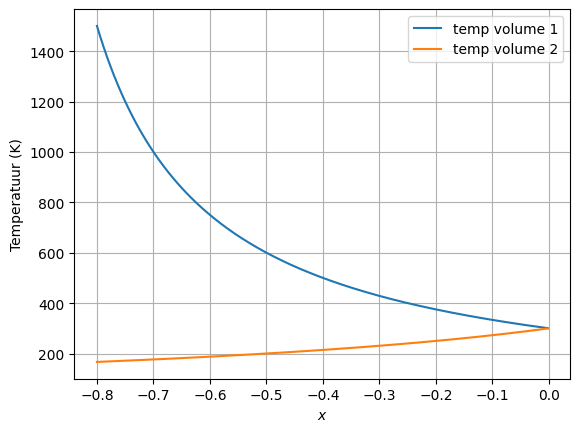

In [9]:
# adiabatische verplaatsing zonder warmtetransfer
import numpy as np
import matplotlib.pyplot as plt

# doelverplaatsing x ≈ -0.8
target_x = -0.8
final_width1 = (1 + target_x) * BOX_SIZE_0
steps_adiabatic = int(abs(final_width1 - BOX_SIZE_0) / (abs(V_PISTON_0) * DT))

cv1_ad = ControlVolume(BOX_SIZE_0, BOX_SIZE_0, 0, V_PISTON_0, 300)
cv2_ad = ControlVolume(BOX_SIZE_0, BOX_SIZE_0, 0, -V_PISTON_0, 300)

volumes1_ad = []
volumes2_ad = []
temperatures1_ad = []
temperatures2_ad = []

for _ in range(steps_adiabatic):
    cv1_ad.take_time_step()
    cv2_ad.take_time_step()
    volumes1_ad.append(cv1_ad.area)
    volumes2_ad.append(cv2_ad.area)
    temperatures1_ad.append(cv1_ad.temperature)
    temperatures2_ad.append(cv2_ad.temperature)

# visualiseer het temperatuurverloop
x_ad = np.array(volumes1_ad) / V0 - 1
plt.figure()
plt.plot(x_ad, temperatures1_ad, label="temp volume 1")
plt.plot(x_ad, temperatures2_ad, label="temp volume 2")
plt.xlabel("$x$")
plt.ylabel("Temperatuur (K)")
plt.legend()
plt.grid(True)
plt.show()


Na de adiabatische verplaatsing moeten de twee volumes alsnog in thermisch evenwicht gebracht worden. Dat doen we met de code hieronder. 
```{exercise} evenwicht
:label: ex-entropy-13
Wat is de theoretische eindtemperatuur $T_{\text{eq}}$ als we deze twee volumes vervolgens in thermisch evenwicht laten komen?
```
```{solution} ex-entropy-13
Voor een ideaal (tweedimensionaal) gas is de inwendige energie van elk beheersvolume proportioneel aan $N k_B T$ en blijft het aantal deeltjes constant.  Na het adiabatische deel (toestand 2) hebben de twee volumes verschillende temperaturen $T_1$ en $T_2$, waarbij volgens de adiabaat geldt $T_i V_i =$ constant.  Als we de volumes vervolgens in thermisch contact brengen zonder de zuiger te bewegen, wordt er warmte uitgewisseld totdat de temperaturen gelijk zijn.  Omdat er geen warmte naar de omgeving wegstroomt, geldt energiebehoud: $N k_B T_1 + N k_B T_2 = 2 N k_B T_{\text{eq}}$, dus  $$T_{\text{eq}} = \tfrac{T_1 + T_2}{2}.$$  Met $T_1 = T_0/(1+x)$ en $T_2 = T_0/(1-x)$ volgt dat  $$T_{\text{eq}} = \frac{1}{2}\Bigl( \frac{T_0}{1+x} + \frac{T_0}{1-x}\Bigr) = \frac{T_0}{1 - x^2}.$$  Voor onze gekozen verplaatsing $x pprox -0{,}8$ met $T_0 = 300\,\text{K}$ wordt dat $T_{\text{eq}} pprox 8{,}3	imes 10^2\,\text{K}$.  In de simulatie zien we dezelfde eindtemperatuur als beide volumes in evenwicht komen.
```


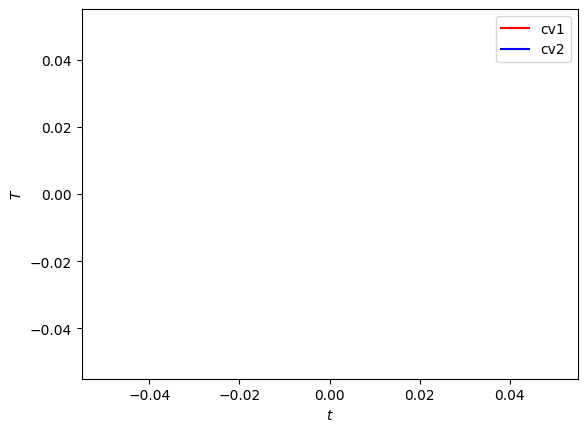

In [10]:
times = []
temp1 = []
temp2 = []

average_temp = (cv1.temperature + cv2.temperature) / 2
cv1.set_temp = average_temp
cv2.set_temp = average_temp
cv1.v_piston = 0.0
cv2.v_piston = 0.0
time = 0.0

while cv2.temperature < 0.99 * cv2.set_temp:
    time += DT
    cv1.take_time_step()
    cv2.take_time_step()
    temp1.append(cv1.temperature)
    temp2.append(cv2.temperature)
    times.append(time)

plt.figure()
plt.xlabel('$t$')
plt.ylabel('$T$')

plt.plot(times, temp1, '-r', label='cv1')
plt.plot(times, temp2, 'b-', label='cv2')
plt.legend()

plt.show()



```{exercise} wrong-contact
:label: ex-entropy-14
Als je kritisch naar de code kijkt staan de twee volumes helemaal niet in thermisch contact met elkaar, maar gebeurt er iets anders.
Omschrijf dat proces en leg uit waarom je hierbij toch hetzelfde antwoord verwacht.
```
```{solution} ex-entropy-14
In de simulatie plaatsen we na de adiabatische verplaatsing de zuigerwand stil en geven beide volumes direct dezelfde temperatuur door het gemiddelde van $T_1$ en $T_2$ te nemen.  Dat stelt geen echte thermische geleiding voor maar eerder een plotselinge vermenging van de deeltjes: alsof de wand wordt verwijderd, de gassen zich mengen en hun energie herverdelen.  Omdat de gassen ideaal zijn en de inwendige energie evenredig is met de temperatuur, leidt deze energiemenging tot hetzelfde eindresultaat als langzaam warmte geleiden via een kleine temperatuurdifferentie.  Het maakt voor de eindtemperatuur niet uit hoe de warmte-uitwisseling plaatsvindt zolang het totale energiebehoud geldt.
```
```{exercise} responstijd
:label: ex-entropy-15
Het antwoord laat zien dat de reactie van de twee volumes een verschillende karakteristieke tijd hebben.
Waardoor wordt dit veroorzaakt?
Hint: stel je hiervoor de stuiterende gasmoleculen voor.
```
```{solution} ex-entropy-15
De gasmoleculen bewegen met een thermische snelheid van honderden meters per seconde en botsen voortdurend.  Daardoor bereiken de deeltjes in elk volume onderling zeer snel een lokaal thermisch evenwicht en reageert de temperatuur vrijwel onmiddellijk op een volumeverandering.  De zuiger heeft daarentegen een macroscopische snelheid die we in de simulatie begrensd hebben; bovendien beweegt hij stapsgewijs in tijd $\mathrm{d}t$.  Het resultaat is dat de gassen zich sneller aanpassen dan de zuigerwand beweegt: er zijn twee verschillende karakteristieke tijden, één voor de thermalisatie van het gas en één voor de beweging van de zuiger.
```


### Vergelijk van de twee experimenten
We hebben de zuiger in twee experimenten verschoven: 
- We begonnen in toestand 0, waarbij de zuiger in het midden stond en naar toestand 1 bewoog, met thermisch contact tussen de twee volumes.
- We begonnen in toestand 0 en verplaatsten de zuiger zonder thermisch contact (adiabatisch) naar toestand 2. Daarna brachten we de twee volumes in thermisch contact en zonder volumeverandering naar evenwicht kwamen in toestand 3.   
Deze processen zijn schematisch weergegeven in {numref}`fig_proces_entropie`.
```{figure} ../../Figures/proces_entropie.png
:width: 50%
:label: fig_proces_entropie
Schematische weergave van de twee processen in een $(p,V)$-diagram met de verschillende toestanden genummerd weergegeven.
```
Uit de thermodynamische formules en uit de simulatie kun je concluderen dat de eindtemperatuur na deze twee experimenten verschillend is.
Omdat we het systeem nooit in thermisch contact met de omgeving hebben gebracht, moet de energie hiervoor uit de arbeid komen die de zuigerwand heeft verricht.
Dit laat zien dat de arbeid die nodig is van de ene in de andere toestand te komen, afhankelijk is van het gekozen proces.
```{exercise} Arbeid
:label: ex-entropy-16
Bereken het verschil in de verrichte arbeid voor beide processen.
Hint: kies je systeem voor elk proces zo dat er geen warmtecontact is naar de omgeving en bereken de arbeid via de interne energie.
```
```{solution} ex-entropy-16
Voor beide processen kiezen we als systeem de twee gasvolumes samen, zodat er geen warmte met de omgeving wordt uitgewisseld ($Q=0$).  De arbeid die de zuiger op het gas verricht is dan gelijk aan de verandering van de inwendige energie: $W_{\text{ext}} = \Delta U = U_{\text{eind}} - U_0$.  Bij het proces met thermisch contact (0→1) hebben beide volumes na afloop dezelfde temperatuur $T_1 = T_0 /\sqrt{1 - x^2}$.  De totale interne energie in toestand 1 bedraagt $U_1 = 2 N k_B T_1$, terwijl in de uitgangstoestand $U_0 = 2 N k_B T_0$.  De vereiste arbeid is dus  $$W_{01} = U_1 - U_0 = 2 N k_B (T_1 - T_0).$$  Voor het adiabatische proces met daarna thermisch contact (0→2→3) eindigen we in toestand 3 met een gemeenschappelijke temperatuur  $T_{\mathrm{eq}} = (T_1 + T_2)/2 = T_0/(1 - x^2)$.  De benodigde arbeid is  $$W_{03} = 2 N k_B (T_{\mathrm{eq}} - T_0).$$  Omdat $T_{\mathrm{eq}} > T_1$ is het adiabatische proces dus energetisch duurder; de extra arbeid bedraagt  $$\Delta W = W_{03} - W_{01} = 2 N k_B \Bigl( \frac{T_0}{1 - x^2} - \frac{T_0}{\sqrt{1 - x^2}} \Bigr).$$  Voor de verplaatsing in onze simulatie met $x pprox -1/3$ en $T_0=300\,\text{K}$ levert dit met $N=40$ en $k_B=1{,}38	imes 10^{-23}\,\text{J\,K}^{-1}$ numeriek ongeveer  $W_{01} pprox 2{,}0	imes 10^{-20}\,\text{J}$ en $W_{03} pprox 4{,}1	imes 10^{-20}\,\text{J}$, zodat $\Delta W pprox 2{,}1	imes 10^{-20}\,\text{J}$.
```
Een reversibele route is dan het 'goedkoopste' proces om in een toestand te komen. Voor het experiment zou het perfect uitgevoerde isotherme proces reversibel zijn en daarom de laagste temperatuur opleveren bij $x=-0.8$.
```{exercise} entropy production
:label: ex-entropy-17
Bereken uit de theoretische, thermodynamische formules hoeveel entropie er vrijkomt bij het tweede proces. 
```
```{solution} ex-entropy-17
Hier jouw antwoord...
De entropieverandering bij het adiabatisch verplaatsen naar toestand 2 is nul als het proces reversibel is.  Alle entropieproductie vindt plaats bij het in thermisch contact brengen van de twee beheersvolumes (toestand 2→3) terwijl de volumes niet van grootte veranderen.  Voor een ideaal tweedimensionaal gas geldt bij warmteoverdracht bij constant volume $\Delta S = N k_B \ln(T_2/T_1)$ per volume.  De totale entropietoename van de twee volumes samen is dan  $$\Delta S_{23} = N k_B \Bigl[ \ln\frac{T_{\mathrm{eq}}}{T_1} + \ln\frac{T_{\mathrm{eq}}}{T_2}\Bigr] = - N k_B \ln(1 - x^2),$$  waar $x$ de eindpositie van de zuiger na de adiabatische verplaatsing is en waarbij we gebruik gemaakt hebben van $T_{\mathrm{eq}} = T_0/(1 - x^2)$ en $T_1 = T_0/(1+x)$ en $T_2 = T_0/(1-x)$.  Dit resultaat is positief voor $|x|<1$, dus er komt entropie vrij.  Voor de verplaatsing uit het vorige experiment ($xpprox -1/3$) met $N=40$ en $k_B=1{,}38	imes 10^{-23}\,\mathrm{J\,K}^{-1}$ vinden we numeriek een entropietoename van ongeveer $6,5	imes 10^{-23}\,\mathrm{J\,K}^{-1}$.  Voor $xpprox -0{,}8$ wordt de entropieproductie nog groter en bedraagt die circa $5{,}6	imes 10^{-22}\,\mathrm{J\,K}^{-1}$.
```
Willen we maximale arbeid halen in de stap van toestand 2 naar toestand 3, dan kunnen we dat doen met twee reversibele warmtepompen die de twee beheersvolumes koppelen aan een denkbeeldig bad. Entropie is een toestandsgrootheid, zodat de entropieproductie in dit proces net zo groot moet zijn als in onze zuiger van daarnet. Voor een reversibel proces zoals we met deze warmtepompen uitvoeren is er geen entropieproductie. Dan moet er dus gelden dat:
$$
    \Delta S_{\text{sys}} + \Delta S_{\text{omg}} = 0 
$$
Als we de omgevingstemperatuur op een waarde stellen van $T_{\text{omg}}$ dan moet er dus gelden:
$$
    \Delta S_{\text{omg}} = -\frac{Q_{\text{rev}}}{T_{\text{omg}}} \Rightarrow Q_{\text{rev}} = T_{\text{omg}} \Delta S_{\text{sys}}
$$
Dit betekent dat het systeem tijdens dit reversibele proces deze hoeveelheid $Q_{\text{rev}}$ moet accepteren van de omgeving om de eindtoestand te bereiken. 
Omdat we daarnaast van de eerste hoofdwet weten dat:
$$
    \Delta U_{\text{sys}} = Q_{\text{rev}} - W_{\text{rev}}
$$
en er moet gelden dat de interne energie van het systeem niet verandert tijdens dit temperatuurverloop kunnen we concluderen dat:
$$
    W_{\text{max}} = W_{\text{rev}} = T_{\text{omg}} \Delta S_{\text{sys}} = N k_B T_{\text{omg}} \ln{\frac{25}{9}}
$$
In het proces dat bij onze simulatie heeft plaatsgevonden is er geen enkele arbeid door het systeem uitgevoerd.
We zien dus dat de entropie die we in dit geval hebben berekend een maat is voor de arbeid die we hadden kunnen winnen door op dezelfde eindtoestand te komen via een reversibel proces. 
We kunnen dit ook andersom zeggen: de hoeveelheid entropie die tijdens het proces gecreëerd wordt is een maat voor de hoeveelheid beschikbare arbeid die we tijdens het proces hebben verloren door het niet perfect reversibel uit te voeren. 
```{note}
Dit concept van verloren arbeid wordt verder uitgewerkt met de grootheid 'exergie' die wordt behandeld in hoofdstuk 7 van het boek. Deze is geen onderdeel van de stof van het vak thermodynamica van dit kwartaal. 
```
```{exercise}
Push je werk naar GitHub.
```
